**House Prices Prediction Model.** 

**Data Loading and Initial Validation**

In [13]:
# Data Loading and Preprocessing
import pandas as pd
import numpy as np
import os



In [14]:
# Load the dataset

from pathlib import Path

data_path = Path("c:/Users/chris/Documents/House_Price_Prediction/dataset_2.csv")
print(data_path.exists(), data_path)

df = pd.read_csv(data_path)
df.head()

True c:\Users\chris\Documents\House_Price_Prediction\dataset_2.csv


,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [15]:
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (1124, 9)
Number of rows: 1124
Number of columns: 9


In [16]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nInfo:")
df.info()
print("\nData types:")
print(df.dtypes)

print("\nInfo:")
df.info()


Shape: (1124, 9)

Data types:
Area_SqFt        float64
Rooms            float64
Build_Year         int64
Location             str
Street_Type          str
Furnishing           str
Property_Type        str
Has_Pool             str
Price            float64
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_SqFt      1091 non-null   float64
 1   Rooms          1091 non-null   float64
 2   Build_Year     1124 non-null   int64  
 3   Location       1124 non-null   str    
 4   Street_Type    1124 non-null   str    
 5   Furnishing     1091 non-null   str    
 6   Property_Type  1124 non-null   str    
 7   Has_Pool       1124 non-null   str    
 8   Price          1124 non-null   float64
dtypes: float64(3), int64(1), str(5)
memory usage: 79.2 KB

Data types:
Area_SqFt        float64
Rooms            float64
Build_Year         int6

In [17]:
print("\n--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
     Area_SqFt  Rooms  Build_Year Location       Street_Type      Furnishing  \
0  2473.192784    4.0        1992   Jaipur  Residential Lane       Furnished   
1  2353.472711    4.0        2006   Indore       Corner Plot     Unfurnished   
2  2212.222005    3.0        2012   Jaipur    Highway Facing  Semi-Furnished   
3  2823.886596    6.0        1993  Lucknow         Main Road     Unfurnished   
4  1869.648721    5.0        2012   Jaipur       Corner Plot  Semi-Furnished   

  Property_Type Has_Pool     Price  
0     Apartment       No  568486.0  
1     Apartment      Yes  577214.0  
2        Duplex       No  581300.0  
3         Villa      Yes  794614.0  
4     Apartment       No  493086.0  


**Data Cleaning and Preprocessing**

In [18]:
# Check for missing values in each column
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

print("Missing values by column:")
print(missing_counts)

print("\nMissing values percentage by column:")
print(missing_percent.round(2))

Missing values by column:
Area_SqFt        33
Rooms            33
Build_Year        0
Location          0
Street_Type       0
Furnishing       33
Property_Type     0
Has_Pool          0
Price             0
dtype: int64

Missing values percentage by column:
Area_SqFt        2.94
Rooms            2.94
Build_Year       0.00
Location         0.00
Street_Type      0.00
Furnishing       2.94
Property_Type    0.00
Has_Pool         0.00
Price            0.00
dtype: float64


In [19]:
# Check the extent and distribution of missing data in key variables to understand 
# whether missing values occur individually or across multiple columns.
missing_mask = df[['Area_SqFt', 'Rooms', 'Furnishing']].isna()
print(missing_mask.sum())
print()
print("Rows missing all three:", (missing_mask.sum(axis=1) == 3).sum())
print("Rows missing exactly one:", (missing_mask.sum(axis=1) == 1).sum())
print("Rows missing exactly two:", (missing_mask.sum(axis=1) == 2).sum())

Area_SqFt     33
Rooms         33
Furnishing    33
dtype: int64

Rows missing all three: 0
Rows missing exactly one: 95
Rows missing exactly two: 2


In [20]:
# ...existing code...
""" 
Cell generated by Data Wrangler.
"""
def clean_data(X):
    # Work on a copy to avoid side effects
    X = X.copy()

    # Normalize common source column name variants to the lowercase names used later
    rename_map = {}
    if 'Area_SqFt' in X.columns and 'area_sqft' not in X.columns:
        rename_map['Area_SqFt'] = 'area_sqft'
    if 'Rooms' in X.columns and 'rooms' not in X.columns:
        rename_map['Rooms'] = 'rooms'
    if 'Furnishing' in X.columns and 'furnishing' not in X.columns:
        rename_map['Furnishing'] = 'furnishing'

    if rename_map:
        X = X.rename(columns=rename_map)

    # Replace missing values with 0 in numeric columns when they exist
    fill_map = {}
    if 'area_sqft' in X.columns:
        fill_map['area_sqft'] = 0
    if 'rooms' in X.columns:
        fill_map['rooms'] = 0
    if fill_map:
        X = X.fillna(fill_map)

    # Drop rows with missing data in column: 'furnishing' (only if column exists)
    if 'furnishing' in X.columns:
        X = X.dropna(subset=['furnishing'])

    return X

# Use the loaded dataframe 'df' (not an undefined variable)
X_clean = clean_data(df.copy())
X_clean.head()
# ...existing code...

,area_sqft,rooms,Build_Year,Location,Street_Type,furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [21]:
# Detect outliers in all numeric columns using the Interquartile Range (IQR) method,
# then summarize the number of outliers per column and identify rows containing
# at least one outlier for further investigation.
numeric_cols = df.select_dtypes(include=[np.number]).columns

q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)
outlier_counts = outlier_mask.sum()

print("Outlier counts by numeric column:")
print(outlier_counts)

print("\nRows with any numeric outlier:")
outlier_rows = df[outlier_mask.any(axis=1)]
print(outlier_rows[numeric_cols].head(10))

print(f"\nTotal rows with at least one numeric outlier: {len(outlier_rows)}")

Outlier counts by numeric column:
Area_SqFt     18
Rooms          0
Build_Year     0
Price         15
dtype: int64

Rows with any numeric outlier:
       Area_SqFt  Rooms  Build_Year        Price
7    4316.818615    6.0        2008   988286.819
52   5648.321783    7.0        2003  1355674.054
134  3496.557001    7.0        2021  1031661.000
137   700.000000    6.0        1987   310136.000
211  5505.772234    5.0        1995  1284263.922
232  3223.723578    7.0        2008   981429.000
234   700.000000    5.0        2014   340017.000
286  6170.583006    2.0        2022  1265986.684
339  4122.732784    2.0        1987   783551.000
428  9022.275608    6.0        2001  1396460.448

Total rows with at least one numeric outlier: 23


In [22]:
# Create a separate cleaned copy so the original dataset remains available for comparison
# This keeps all columns intact while improving data quality more carefully.
df_clean = df.copy()

# 1) Standardize missing values in text/object columns
# Some datasets store missing values as empty strings, 'None', or 'nan' text.
# Converting them to actual NaN values makes them easier to handle consistently.
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].astype('string').str.strip()
    df_clean[col] = df_clean[col].replace({'nan': np.nan, 'None': np.nan, 'null': np.nan, '': np.nan})

# 2) Convert numeric-looking columns to numeric data types
# This helps avoid issues where numbers are stored as strings.
# The list below includes common house-price related numeric fields.
numeric_columns = [col for col in ['Area_SqFt', 'Rooms', 'Bedrooms', 'Bathrooms', 'Parking', 'Price'] if col in df_clean.columns]
for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 3) Standardize common placeholder text values in categorical columns
# This reduces the number of inconsistent category labels and makes later imputation more reliable.
for col in df_clean.select_dtypes(exclude=[np.number]).columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace({'unknown': np.nan, 'Unknown': np.nan, 'N/A': np.nan, 'NA': np.nan, 'none': np.nan, 'None': np.nan})

# 4) Handle impossible numeric values by treating them as missing
# Zero or negative values in house-related numeric features are often invalid or suspicious,
# so they are converted to NaN and then imputed later.
for col in ['Area_SqFt', 'Rooms', 'Bedrooms', 'Bathrooms', 'Parking', 'Price']:
    if col in df_clean.columns:
        df_clean.loc[df_clean[col] <= 0, col] = np.nan

# 5) Check for duplicate rows
# Duplicates can distort analysis and model training, so it is useful to flag them early.
duplicate_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# 6) Check for suspicious relationships between columns
# These are simple sanity checks to spot values that may be unrealistic.
if {'Bedrooms', 'Rooms'}.issubset(df_clean.columns):
    suspicious_bedroom_count = (df_clean['Bedrooms'] > df_clean['Rooms']).sum()
    print(f"Rows where Bedrooms > Rooms: {suspicious_bedroom_count}")

if {'Bathrooms', 'Rooms'}.issubset(df_clean.columns):
    suspicious_bathroom_count = (df_clean['Bathrooms'] > df_clean['Rooms']).sum()
    print(f"Rows where Bathrooms > Rooms: {suspicious_bathroom_count}")

# 7) Impute missing values using group-based statistics when possible
# This is often more accurate than using a global average because values can vary by category.
# It will first try to fill missing values using a category-based median or mode.
group_col = next((col for col in ['Furnishing', 'Location', 'City', 'Property_Type', 'Type', 'Neighborhood'] if col in df_clean.columns), None)

for col in df_clean.columns:
    if col == group_col:
        continue

    if pd.api.types.is_numeric_dtype(df_clean[col]):
        # Use the median within each group first, then fall back to the overall median.
        if group_col is not None:
            group_medians = df_clean.groupby(group_col)[col].transform('median')
            df_clean[col] = df_clean[col].fillna(group_medians)

        overall_median = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(overall_median)

    else:
        # Use the mode within each group first, then fall back to the overall mode.
        if group_col is not None:
            group_modes = df_clean.groupby(group_col)[col].transform(
                lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else np.nan
            )
            df_clean[col] = df_clean[col].fillna(group_modes)

        mode_value = df_clean[col].mode(dropna=True)
        if not mode_value.empty:
            df_clean[col] = df_clean[col].fillna(mode_value.iloc[0])

# 8) Handle outliers more carefully by capping extreme values instead of dropping them
# This preserves the full dataset while reducing the effect of extreme values on analysis.
for col in df_clean.select_dtypes(include=[np.number]).columns:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    if pd.notna(iqr) and iqr != 0:
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

# 9) Review the cleaned result
# This gives you a quick check that missing values were handled properly.
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("\nRemaining missing values after cleaning:")
print(df_clean.isna().sum())


Number of duplicate rows: 0
Original shape: (1124, 9)
Cleaned shape: (1124, 9)

Remaining missing values after cleaning:
Area_SqFt         0
Rooms             0
Build_Year        0
Location          0
Street_Type       0
Furnishing       33
Property_Type     0
Has_Pool          0
Price             0
dtype: int64


C:\Users\chris\AppData\Local\Temp\ipykernel_13888\261853277.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object']).columns:


In [23]:
# Compare key numeric columns before and after cleaning
# This helps you check whether the cleaning process made the data more reasonable.

numeric_cols = [col for col in ['Area_SqFt', 'Rooms', 'Bedrooms', 'Bathrooms', 'Parking', 'Price'] if col in df.columns and col in df_clean.columns]

print("Summary of numeric columns before and after cleaning:")
print("-" * 70)

for col in numeric_cols:
    before = df[col]
    after = df_clean[col]
    print(f"{col}:")
    print(f"  Before -> mean: {before.mean():.2f}, median: {before.median():.2f}, std: {before.std():.2f}")
    print(f"  After  -> mean: {after.mean():.2f}, median: {after.median():.2f}, std: {after.std():.2f}")
    print()


Summary of numeric columns before and after cleaning:
----------------------------------------------------------------------
Area_SqFt:
  Before -> mean: 2237.48, median: 2201.55, std: 731.10
  After  -> mean: 2207.87, median: 2199.75, std: 557.42

Rooms:
  Before -> mean: 4.57, median: 5.00, std: 1.68
  After  -> mean: 4.57, median: 5.00, std: 1.66

Price:
  Before -> mean: 608201.51, median: 602541.00, std: 143195.81
  After  -> mean: 604688.34, median: 602541.00, std: 126637.91



**Fix Data Types**

In [24]:
# Fix data types for cleaner modeling
# This step makes sure categorical columns are treated as categories and numeric columns stay numeric.

# Convert commonly numeric columns to numeric if they are not already
for col in ['Area_SqFt', 'Rooms', 'Bedrooms', 'Bathrooms', 'Parking', 'Price']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Convert object/string columns that are truly categorical into category dtype
for col in df_clean.select_dtypes(include=['string', 'object']).columns:
    # Keep only columns that are not too unique to be useful as categories
    if df_clean[col].nunique(dropna=True) < 50:
        df_clean[col] = df_clean[col].astype('category')

# Review the updated data types
print("Updated data types:")
print(df_clean.dtypes)


Updated data types:
Area_SqFt         float64
Rooms             float64
Build_Year          int64
Location         category
Street_Type      category
Furnishing       category
Property_Type    category
Has_Pool         category
Price             float64
dtype: object


Saved plot: c:\Users\chris\Documents\House_Price_Prediction\Visualizations\plots\price_distribution.png


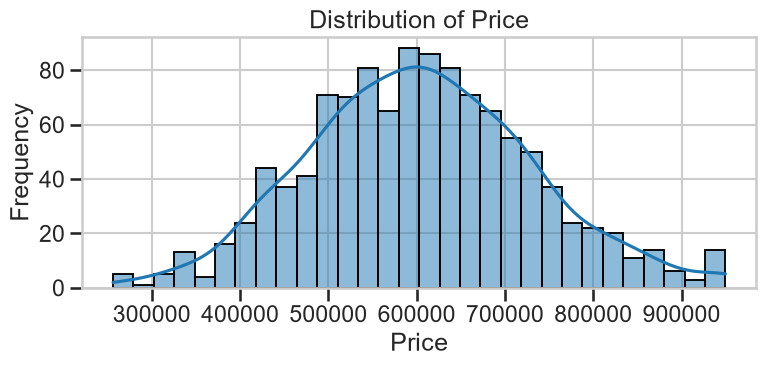

Saved plot: c:\Users\chris\Documents\House_Price_Prediction\Visualizations\plots\price_vs_area.png


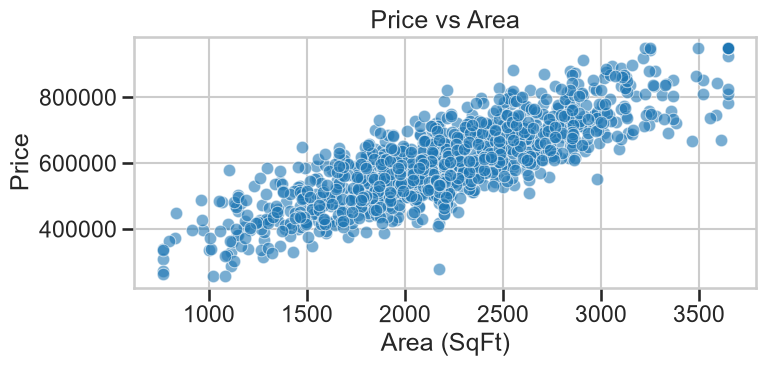

Saved plot: c:\Users\chris\Documents\House_Price_Prediction\Visualizations\plots\price_by_rooms.png


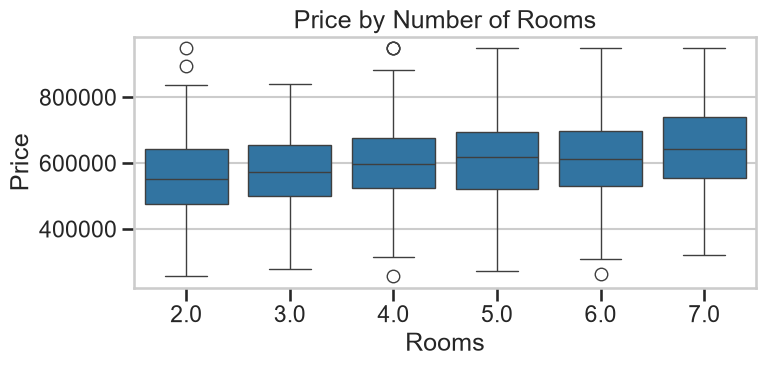

Saved plot: c:\Users\chris\Documents\House_Price_Prediction\Visualizations\plots\price_by_furnishing.png


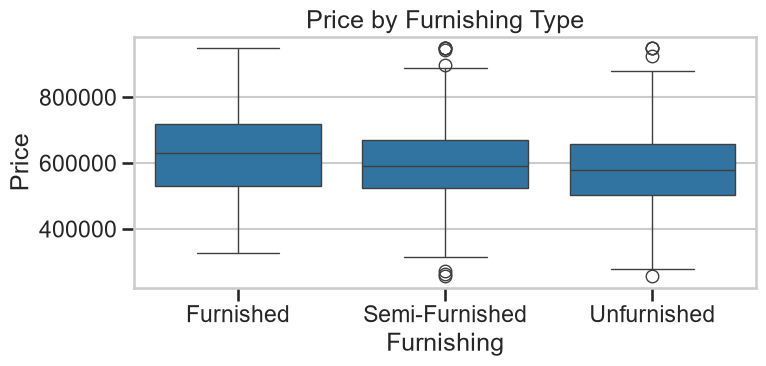

Saved plot: c:\Users\chris\Documents\House_Price_Prediction\Visualizations\plots\price_by_property_type.png


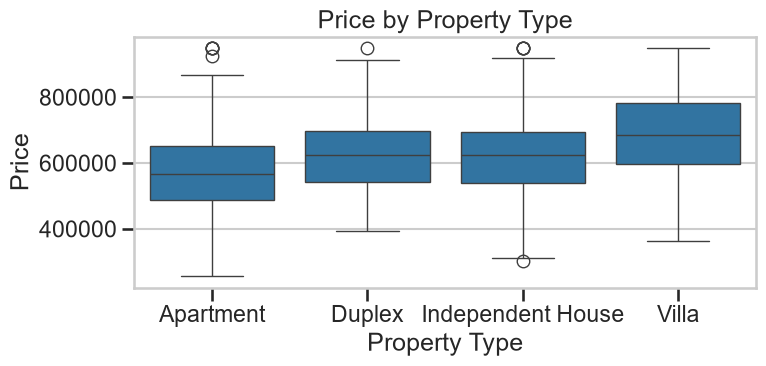

Saved plot: c:\Users\chris\Documents\House_Price_Prediction\Visualizations\plots\correlation_heatmap.png


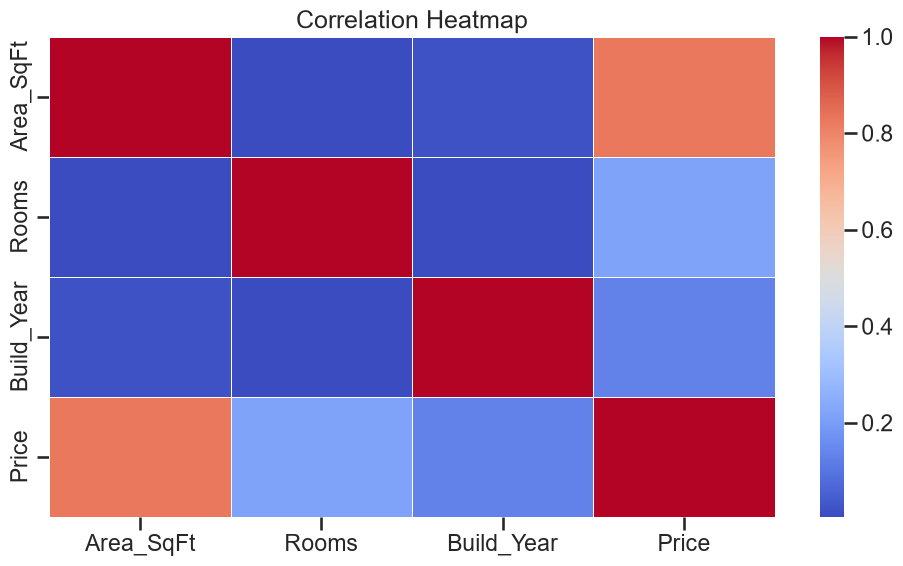

In [25]:
# Visualizations for Exploratory Data Analysis
# These plots help you inspect the distribution of key variables and their relationship to price.

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Set a cleaner visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

# Configure the output folder for saved plots
plots_dir = Path('c:/Users/chris/Documents/House_Price_Prediction/Visualizations/plots')
plots_dir.mkdir(parents=True, exist_ok=True)

# Helper function to save plots and display them

def save_and_show(fig, filename):
    filepath = plots_dir / filename
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {filepath}')
    display(fig)
    plt.close(fig)

# Use whichever column names exist in the dataset.
price_col = next((c for c in ['Price', 'price'] if c in df_clean.columns), None)
area_col = next((c for c in ['Area_SqFt', 'area_sqft'] if c in df_clean.columns), None)
rooms_col = next((c for c in ['Rooms', 'rooms'] if c in df_clean.columns), None)
furnishing_col = next((c for c in ['Furnishing', 'furnishing'] if c in df_clean.columns), None)
property_type_col = next((c for c in ['Property_Type', 'property_type'] if c in df_clean.columns), None)

# 1) Distribution of the target variable if it exists
if price_col is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(df_clean[price_col], kde=True, bins=30, ax=ax)
    ax.set_title('Distribution of Price')
    ax.set_xlabel('Price')
    ax.set_ylabel('Frequency')
    fig.tight_layout()
    save_and_show(fig, 'price_distribution.png')
else:
    print('Skipping price distribution plot because no Price column was found.')

# 2) Relationship between Price and Area
if price_col is not None and area_col is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.scatterplot(data=df_clean, x=area_col, y=price_col, alpha=0.6, ax=ax)
    ax.set_title('Price vs Area')
    ax.set_xlabel('Area (SqFt)')
    ax.set_ylabel('Price')
    fig.tight_layout()
    save_and_show(fig, 'price_vs_area.png')
else:
    print('Skipping price vs area plot because required columns were not found.')

# 3) Relationship between Price and Rooms
if price_col is not None and rooms_col is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=df_clean, x=rooms_col, y=price_col, ax=ax)
    ax.set_title('Price by Number of Rooms')
    ax.set_xlabel('Rooms')
    ax.set_ylabel('Price')
    fig.tight_layout()
    save_and_show(fig, 'price_by_rooms.png')
else:
    print('Skipping price by rooms plot because required columns were not found.')

# 4) Categorical plot for Furnishing if available
if price_col is not None and furnishing_col is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=df_clean, x=furnishing_col, y=price_col, ax=ax)
    ax.set_title('Price by Furnishing Type')
    ax.set_xlabel('Furnishing')
    ax.set_ylabel('Price')
    fig.tight_layout()
    save_and_show(fig, 'price_by_furnishing.png')
else:
    print('Skipping price by furnishing plot because required columns were not found.')

# 5) Categorical plot for Property_Type if available
if price_col is not None and property_type_col is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=df_clean, x=property_type_col, y=price_col, ax=ax)
    ax.set_title('Price by Property Type')
    ax.set_xlabel('Property Type')
    ax.set_ylabel('Price')
    fig.tight_layout()
    save_and_show(fig, 'price_by_property_type.png')
else:
    print('Skipping price by property type plot because required columns were not found.')

# 6) Correlation heatmap for numeric columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    fig, ax = plt.subplots(figsize=(10, 6))
    corr_matrix = df_clean[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, ax=ax)
    ax.set_title('Correlation Heatmap')
    fig.tight_layout()
    save_and_show(fig, 'correlation_heatmap.png')
else:
    print('Skipping correlation heatmap because there are not enough numeric columns.')


**Rename & Select Columns**

In [26]:
# Rename and select columns for modeling
# This section runs after exploratory analysis and visualization.

rename_map = {
    'Area_SqFt': 'area_sqft',
    'Rooms': 'rooms',
    'Bedrooms': 'bedrooms',
    'Bathrooms': 'bathrooms',
    'Parking': 'parking',
    'Price': 'price',
    'Furnishing': 'furnishing',
    'Property_Type': 'property_type',
    'Location': 'location',
    'City': 'city',
    'Neighborhood': 'neighborhood',
    'Type': 'property_subtype'
}

rename_map = {old: new for old, new in rename_map.items() if old in df_clean.columns}
df_clean = df_clean.rename(columns=rename_map)

print('Renamed columns:')
print(rename_map)

selected_columns = [
    'price',
    'area_sqft',
    'rooms',
    'bedrooms',
    'bathrooms',
    'parking',
    'furnishing',
    'property_type',
    'location',
    'city',
    'neighborhood',
    'property_subtype'
]

selected_columns = [col for col in selected_columns if col in df_clean.columns]
df_model = df_clean[selected_columns].copy()

print('\nSelected columns for modeling:')
print(df_model.columns.tolist())
print('\nModel dataset shape:', df_model.shape)


Renamed columns:
{'Area_SqFt': 'area_sqft', 'Rooms': 'rooms', 'Price': 'price', 'Furnishing': 'furnishing', 'Property_Type': 'property_type', 'Location': 'location'}

Selected columns for modeling:
['price', 'area_sqft', 'rooms', 'furnishing', 'property_type', 'location']

Model dataset shape: (1124, 6)


In [27]:
# Show the dataset with renamed columns and selected modeling columns
print('Renamed and selected dataset preview:')
try:
    display(df_model.head())
except NameError:
    print('df_model is not defined yet. Run the rename and select cell first.')

print('\nColumns in df_model:')
print(df_model.columns.tolist() if 'df_model' in globals() else 'df_model not defined')
print('\nShape of df_model:', df_model.shape if 'df_model' in globals() else 'df_model not defined')


Renamed and selected dataset preview:


,price,area_sqft,rooms,furnishing,property_type,location
0,568486.0,2473.192784,4.0,Furnished,Apartment,Jaipur
1,577214.0,2353.472711,4.0,Unfurnished,Apartment,Indore
2,581300.0,2212.222005,3.0,Semi-Furnished,Duplex,Jaipur
3,794614.0,2823.886596,6.0,Unfurnished,Villa,Lucknow
4,493086.0,1869.648721,5.0,Semi-Furnished,Apartment,Jaipur



Columns in df_model:
['price', 'area_sqft', 'rooms', 'furnishing', 'property_type', 'location']

Shape of df_model: (1124, 6)


**Feature Engineering and Model Training**

In [28]:
# Feature engineering and model training
# This cell starts the modeling workflow using df_model as the prepared dataset.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import root_mean_squared_error

# Make sure df_model exists and has the expected target
if 'df_model' not in globals():
    raise NameError('df_model is not defined. Run the rename/select section first.')

# Define target and feature matrix
if 'price' not in df_model.columns:
    raise KeyError('Target column price not found in df_model. Check your rename/select step.')

X = df_model.drop(columns=['price'])
y = df_model['price']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit a simple linear regression model
model = LinearRegression()
# Encode categorical columns
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

categorical_features = X_train_encoded.select_dtypes(include=['object', 'category']).columns

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col].astype(str))
    X_test_encoded[col] = le.transform(X_test_encoded[col].astype(str))
    label_encoders[col] = le

model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)

print('Linear Regression results:')
print('RMSE:', root_mean_squared_error(y_test, y_pred))
print('R^2:', r2_score(y_test, y_pred))

# Show coefficient summary if the data has numeric columns only
coef_summary = {
    'feature': X.columns.tolist(),
    'coefficient': model.coef_.tolist()
}
print('\nModel coefficients:')
print(coef_summary)


Linear Regression results:
RMSE: 47333.983925732115
R^2: 0.8720988985496273

Model coefficients:
{'feature': ['area_sqft', 'rooms', 'furnishing', 'property_type', 'location'], 'coefficient': [185.07139451181348, 17225.87485069305, -21845.467052063734, 33495.671978917024, -7441.526158834893]}


**Model Validation and Diagnostics**

5-fold CV RMSE scores: [52675.08170452 52714.19082202 50701.54392883 50962.36249617
 47296.81368229]
Mean CV RMSE: 50869.99852676492


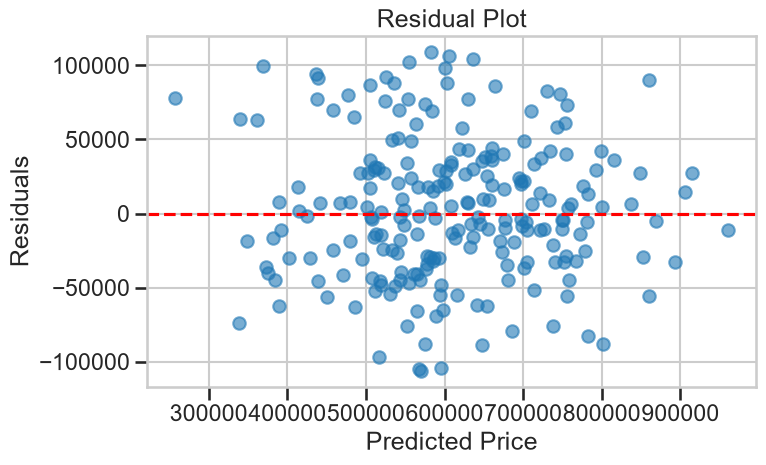

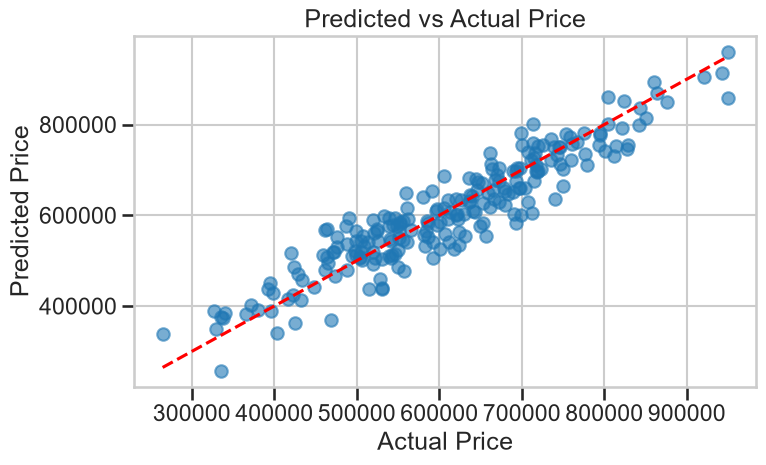

In [29]:
# Model validation and diagnostics
# This section evaluates the trained model and plots residuals and predictions.

import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

if 'model' not in globals() or 'X_test_encoded' not in globals() or 'y_test' not in globals():
    raise NameError('Model or test data not found. Run the feature engineering/model training cell first.')

# Cross-validation on the full dataset
X_encoded = pd.concat([X_train_encoded, X_test_encoded], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

cv_scores = cross_val_score(model, X_encoded, y_full, cv=5, scoring='neg_root_mean_squared_error')
print('5-fold CV RMSE scores:', -cv_scores)
print('Mean CV RMSE:', -cv_scores.mean())

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

# Predicted vs actual plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Price')
plt.tight_layout()
plt.show()


**Model Comparison: Linear Regression vs Tree-Based Models**

In [30]:
# Train additional models and compare with Linear Regression
# This cell trains RandomForestRegressor and GradientBoostingRegressor on the same data,
# then compares all three models side-by-side using RMSE, R², and cross-validation scores.

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd

if 'X_train_encoded' not in globals() or 'y_train' not in globals():
    raise NameError('Training data not found. Run the feature engineering/model training cell first.')

# Train RandomForestRegressor
print("Training RandomForestRegressor...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_encoded, y_train)
rf_pred = rf_model.predict(X_test_encoded)
rf_rmse = root_mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# Train GradientBoostingRegressor
print("Training GradientBoostingRegressor...")
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_encoded, y_train)
gb_pred = gb_model.predict(X_test_encoded)
gb_rmse = root_mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

# Retrieve Linear Regression metrics
lr_rmse = root_mean_squared_error(y_test, y_pred)
lr_r2 = r2_score(y_test, y_pred)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse],
    'R²': [lr_r2, rf_r2, gb_r2]
})

print("\n" + "="*60)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Cross-validation scores for all models
print("\nCross-Validation Performance (5-fold):")
print("-"*60)

# Linear Regression CV
lr_cv_scores = cross_val_score(model, X_encoded, y_full, cv=5, scoring='neg_root_mean_squared_error')
print(f"Linear Regression - Mean CV RMSE: {-lr_cv_scores.mean():.2f} (+/- {lr_cv_scores.std():.2f})")

# Random Forest CV
rf_cv_scores = cross_val_score(rf_model, X_encoded, y_full, cv=5, scoring='neg_root_mean_squared_error')
print(f"Random Forest - Mean CV RMSE: {-rf_cv_scores.mean():.2f} (+/- {rf_cv_scores.std():.2f})")

# Gradient Boosting CV
gb_cv_scores = cross_val_score(gb_model, X_encoded, y_full, cv=5, scoring='neg_root_mean_squared_error')
print(f"Gradient Boosting - Mean CV RMSE: {-gb_cv_scores.mean():.2f} (+/- {gb_cv_scores.std():.2f})")

# Feature importance comparison for tree-based models
print("\n" + "="*60)
print("FEATURE IMPORTANCE - TREE-BASED MODELS")
print("="*60)

feature_names = X_train_encoded.columns.tolist()

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Random Forest': rf_model.feature_importances_,
    'Gradient Boosting': gb_model.feature_importances_
})

rf_importance_df = rf_importance_df.sort_values('Random Forest', ascending=False)
print("\nRandom Forest - Top Features:")
print(rf_importance_df[['Feature', 'Random Forest']].head(10).to_string(index=False))

print("\nGradient Boosting - Top Features:")
gb_importance_df = rf_importance_df.sort_values('Gradient Boosting', ascending=False)
print(gb_importance_df[['Feature', 'Gradient Boosting']].head(10).to_string(index=False))

Training RandomForestRegressor...
Training GradientBoostingRegressor...

MODEL COMPARISON - TEST SET PERFORMANCE
            Model         RMSE       R²
Linear Regression 47333.983926 0.872099
    Random Forest 45456.203957 0.882046
Gradient Boosting 44134.398010 0.888806

Cross-Validation Performance (5-fold):
------------------------------------------------------------
Linear Regression - Mean CV RMSE: 50870.00 (+/- 1973.01)
Random Forest - Mean CV RMSE: 49294.35 (+/- 2724.10)
Gradient Boosting - Mean CV RMSE: 46209.24 (+/- 1984.41)

FEATURE IMPORTANCE - TREE-BASED MODELS

Random Forest - Top Features:
      Feature  Random Forest
    area_sqft       0.748561
property_type       0.091129
     location       0.064309
        rooms       0.064146
   furnishing       0.031854

Gradient Boosting - Top Features:
      Feature  Gradient Boosting
    area_sqft           0.741393
property_type           0.098916
     location           0.066301
        rooms           0.062197
   furnishing 